In [1]:
using Oceananigans
using JLD2
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")

[ Info: Oceananigans will use 4 threads


15

Videos and snapshots of all fields $(\overline{u}, \overline{v}, \overline{w}, \overline{b})$ with $\overline{b}$ contours except last one which has streamfunction and removes the average buoyancy (compensates for cooling)
Hovmoller plots
Vertical velocity slices video

In [2]:
include("../src-fig/video/uv_video.jl")

uv_video (generic function with 1 method)

In [ ]:
for run_id in run_ids[2:10]
    foldername = joinpath("../../scratch/turbulence-at-many-fronts/", run_id)
    sp = simulation_parameters(joinpath(foldername, "DFM.jld2"))
    filename = joinpath("../figures/video/cooling-depth", "uv-$(run_id).mp4")
    fig = uv_video(foldername, 1:251, filename, -sp.H/2;
        fig_kw = NamedTuple(),
        record_kw = (; framerate=16),
        background = true,
        coarse = false
    )
    save("../figures/images/cooling-depth/uv-$(run_id).png", fig; px_per_unit=2)
end

80s / 445s (45 / 251)

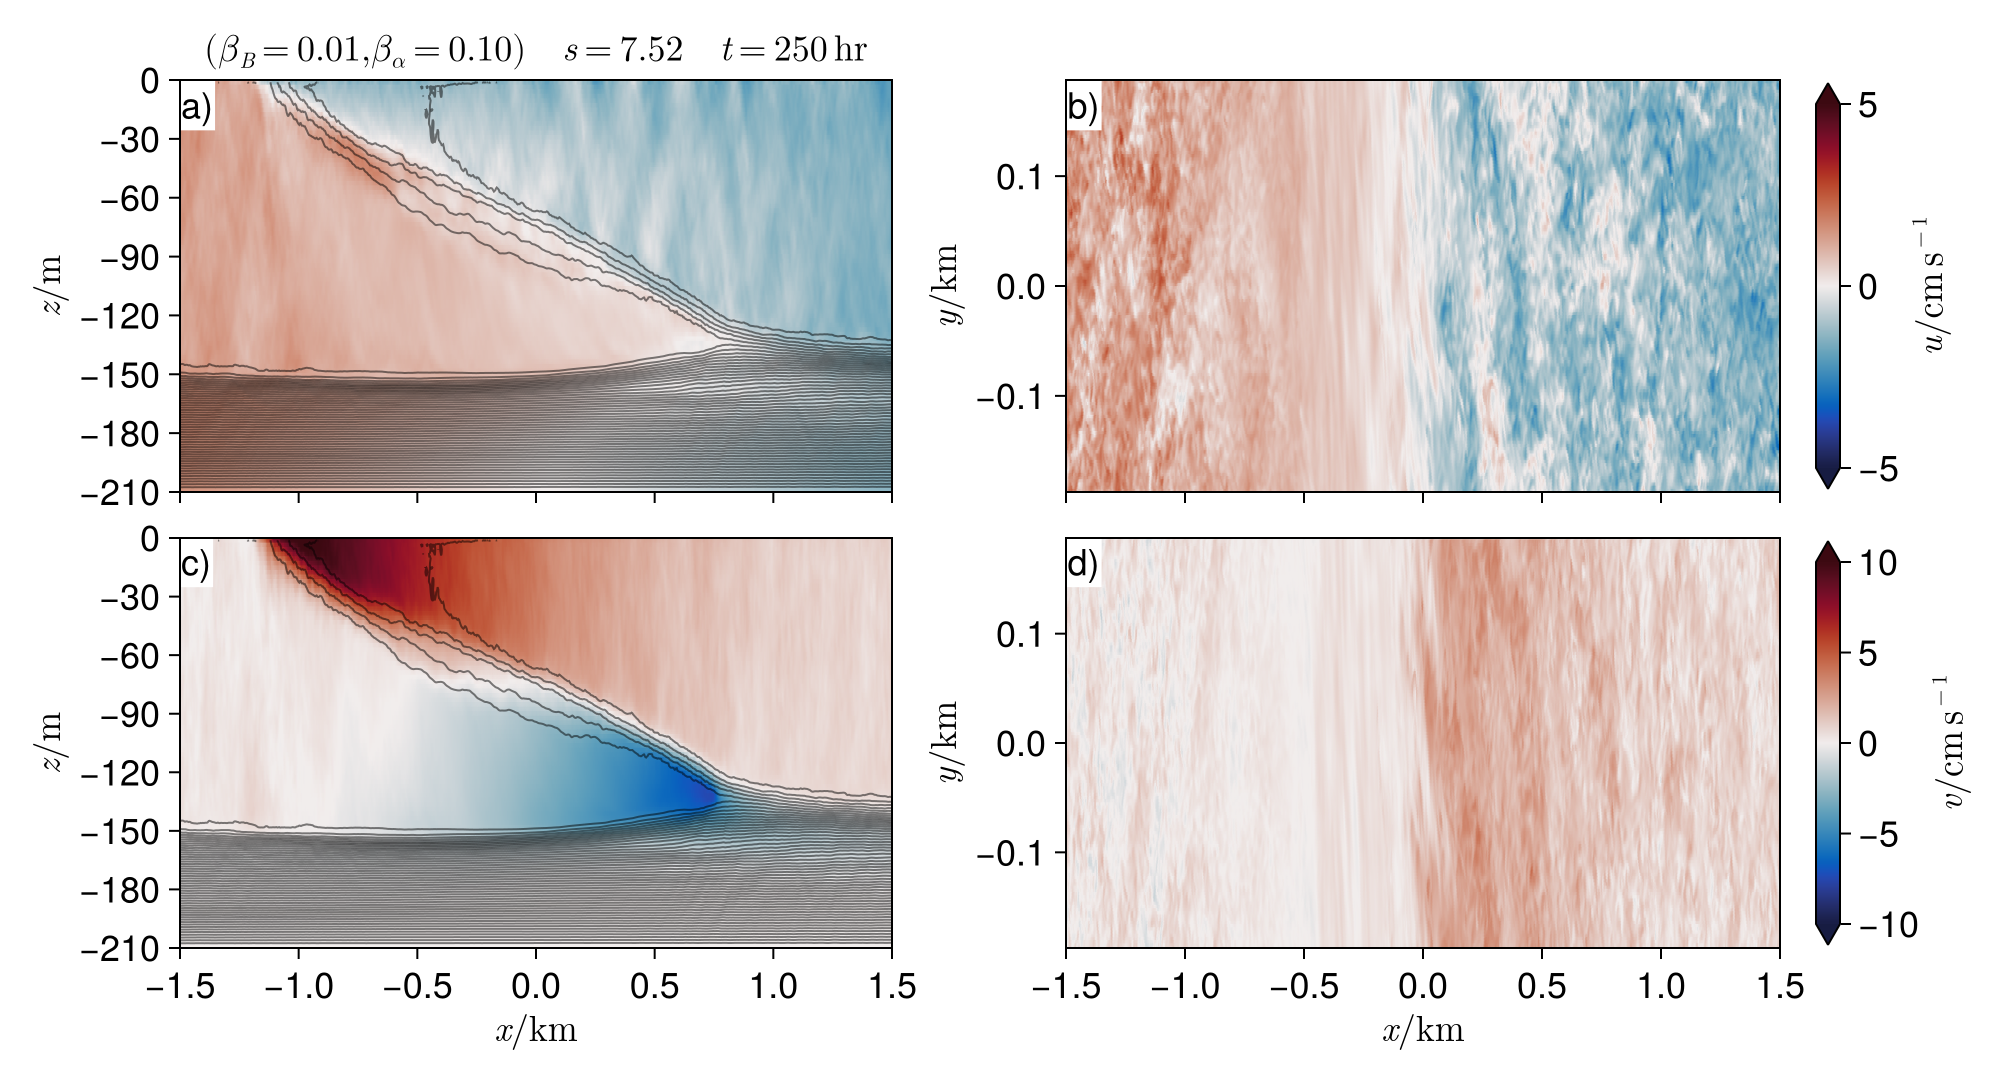

In [23]:
run_id = run_ids[11]
foldername = joinpath("../../scratch/turbulence-at-many-fronts/", run_id)
sp = simulation_parameters(joinpath(foldername, "DFM.jld2"))
filename = joinpath("../figures/video/cooling-depth", "uv-$(run_id).mp4")
fig = uv_video(foldername, [301], filename, -sp.H/2;
    fig_kw = NamedTuple(),
    record_kw = (; framerate=16),
    background = true,
    coarse = false
)

In [12]:
include("../src-fig/figures/hovmoller.jl")
for run_id in run_ids
    foldername = joinpath("../../scratch/turbulence-at-many-fronts/", run_id)
    sp = simulation_parameters(joinpath(foldername, "DFM.jld2"))
    fig = hovmoller(
        foldername,
        -sp.H/2;
        fig_kw=(; size=(800, 400)), 
        ax_kw=(; ),
        ht_kw=(; ),
        ct_kw=(; ),
        σ=0,
        background=true,
    )
    save("../figures/images/cooling-depth/hovmoller-$(run_id).png", fig; px_per_unit=2)
end

In [72]:
run_ids[1]

"0_06-0_1-0_01-0_0-C"